# Notebook 02 — EDA: Estación Meteorológica CESMAG

**Proyecto de Grado — Maestría en Ciencia de Datos**  
**Pontificia Universidad Javeriana Cali — Grupo 8**  
**Autores:** Laura García Salamanca, Daniel Sebastián Rosero Usamá, Juan Villalobos Mora

---

## Descripción del dataset
El archivo `Datos_2013_2026_completo.csv` contiene:
- **DateTime**: marca temporal cada 5 minutos (2013-08-01 → 2026-03-25)
- **Irradiancia**: irradiancia solar instantánea en W/m² (variable objetivo)

Las variables meteorológicas complementarias provienen de **NASA POWER** (Notebook 00)
y se integrarán en el preprocesamiento (Notebook 02).

## Contenido
1. Carga y estructura general
2. Análisis de valores faltantes
3. Estadísticas descriptivas
4. Distribución de la irradiancia
5. Patrones temporales
6. Detección de valores atípicos
7. Análisis de gaps temporales
8. Resumen de hallazgos


---
## Cambios de la revision (septiembre de 2026)

Un cambio, y una advertencia.

**El cambio: la franja diurna se define por el reloj.** Este cuaderno llamaba
«diurnos» a los registros con irradiancia positiva. Los cuadernos 06, 07, 09 y
10 la definen por la hora, de 6:00 a 18:55. No son lo mismo: la definicion por
irradiancia positiva **excluye los instantes diurnos realmente oscuros**, que
son justamente los mas dificiles de pronosticar, y por eso produce una media
diurna mas alta. Si el documento cita la media diurna de este cuaderno junto a
las metricas diurnas del 06, esta mezclando dos definiciones. Ahora se reportan
las dos, y la principal es la del reloj.

**La advertencia: la asimetria y la curtosis se calculan pero no van al
cuerpo.** La direccion pidio retirarlas. Se conservan en la tabla que este
cuaderno guarda, porque describir la distribucion tiene sentido en el anexo,
pero el capitulo de datos no debe citarlas.

Este cuaderno es barato de reejecutar: lee el CSV crudo y no depende de nada
mas.

---

In [ ]:
# ── 0. Importaciones ─────────────────────────────────────────────────────
!pip install pandas numpy matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import subprocess
import os
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

# El estilo de las figuras (paleta y tamanos de letra) se define en la celda
# siguiente, la celda de estilo, para que sea identico en los 11 cuadernos.
print('Librerías importadas:', datetime.now().strftime('%Y-%m-%d %H:%M:%S'))

Librerías importadas: 2026-09-09 04:12:25


### Estilo unico de figuras

Esta celda fija la **paleta de colores** y los **tamanos de letra** de todas las figuras del cuaderno. Es la misma celda en los once cuadernos, de modo que cualquier figura del trabajo de grado sale con el mismo aspecto.


In [ ]:
# @@ESTILO_TG@@  (marca unica: no editar esta linea)
# =============================================================================
#  ESTILO UNICO DE FIGURAS DEL TRABAJO DE GRADO
#  Esta celda define la paleta y la tipografia de TODAS las figuras.
#  Es identica en los 11 cuadernos: cambiarla aqui cambia solo este cuaderno,
#  por eso si se modifica hay que modificarla en todos.
#
#  Paleta categorica anclada en el azul. Validada con el verificador de
#  accesibilidad de color (separacion OKLab bajo protanopia y deuteranopia,
#  piso de croma, banda de luminosidad y contraste contra fondo blanco):
#  todos los pares de colores pasan, no solo los contiguos.
# =============================================================================
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from cycler import cycler
try:
    import seaborn as sns
except Exception:
    sns = None

# --- 1. Paleta categorica (orden FIJO: la ranura 1 es siempre la serie principal)
C_AZUL    = '#0C60A3'   # ranura 1 - serie principal / observado / T1 / V1
C_AMBAR   = '#D4771A'   # ranura 2 - segunda serie / modelo / T2 / V2
C_CELESTE = '#269AE6'   # ranura 3 - tercera serie / T3 / V3
C_TEJA    = '#963E35'   # ranura 4 - cuarta serie
C_VERDEAZ = '#0D8F73'   # ranura 5 - quinta serie
PALETA_TG = [C_AZUL, C_AMBAR, C_CELESTE, C_TEJA, C_VERDEAZ]

# --- 2. Tonos de apoyo de la rampa azul (rellenos, bandas, sombreados)
C_AZUL_CLARO  = '#81B4EA'
C_AZUL_MEDIO  = '#5A9BDC'
C_AZUL_OSCURO = '#0A3765'

# --- 3. Tinta neutra: texto, ejes, lineas de referencia. NUNCA es una serie.
C_TEXTO      = '#1A1A1A'
C_GRIS       = '#6E6E6E'
C_GRIS_CLARO = '#C9C9C9'

# --- 4. Mapas de color continuos
#   'tg_azul' : secuencial de un solo tono, claro -> oscuro (magnitudes)
#   'tg_div'  : divergente azul <-> teja con gris neutro en el centro
#               (mantiene la lectura de 'RdBu_r': negativo azul, positivo calido)
_SECUENCIAL = ['#F4F9FF', '#D8E8FA', '#B4D2F4', '#81B4EA', '#5A9BDC',
               '#3581C9', '#1667AC', '#0B4E89', '#0A3765']
_DIVERGENTE = ['#0A3765', '#1667AC', '#5A9BDC', '#AFCEEC', '#F2F1EF',
               '#EFC9AC', '#DC9A5A', '#B4642C', '#7E3A2C']
CMAP_SEC = LinearSegmentedColormap.from_list('tg_azul', _SECUENCIAL)
CMAP_DIV = LinearSegmentedColormap.from_list('tg_div',  _DIVERGENTE)

def _registrar_cmap(cm_obj):
    """Registra el mapa por nombre para poder usar cmap='tg_azul'."""
    try:
        mpl.colormaps.register(cm_obj, force=True)          # matplotlib >= 3.6
    except Exception:
        try:
            mpl.cm.register_cmap(cmap=cm_obj)               # matplotlib antiguo
        except Exception:
            pass

for _c in (CMAP_SEC, CMAP_DIV):
    _registrar_cmap(_c)

def escala_azul(n, ini=0.375, fin=1.0):
    """n colores tomados de la rampa azul. Para variables ORDENADAS (anios,
    meses, horizontes): el orden se lee en el tono, de claro a oscuro."""
    if n <= 1:
        return [C_AZUL]
    paso = (fin - ini) / (n - 1)
    return [CMAP_SEC(ini + i * paso) for i in range(n)]

# --- 6. Eje X de fechas legible ----------------------------------------------
import matplotlib.dates as mdates

def eje_fechas(ax):
    """Ajusta el eje X de fechas al rango real de la serie: anios cuando abarca
    anios, meses cuando abarca meses. Evita que se repita la misma etiqueta
    ('2023 2023 2023 ...') cuando el periodo es corto."""
    loc = mdates.AutoDateLocator(minticks=4, maxticks=9)
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
    return ax

# --- 7. Trazo por serie: si dos curvas se superponen, el trazo las separa -----
ESTILOS_TG = ['-', '--', ':', '-.', (0, (5, 1, 1, 1))]
TRAZO = {'T1': '-', 'T2': '--', 'T3': ':',
         'V1': '-', 'V2': '--', 'V3': ':'}

# --- 5. Tipografia: tamanos grandes para que la figura se lea en el PDF impreso
TAM_BASE = 13          # texto general dentro de la figura
TAM_EJE  = 14          # etiquetas de los ejes X e Y
TAM_TICK = 12          # numeros de los ejes
TAM_TIT  = 14.5        # titulo del panel
TAM_LEY  = 12          # leyenda

plt.rcParams.update({
    # --- color
    'axes.prop_cycle'   : cycler(color=PALETA_TG),
    'image.cmap'        : 'tg_azul',
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'savefig.facecolor' : 'white',
    # --- tipografia (lo que pidio la revision: ejes y etiquetas legibles)
    'font.family'       : 'sans-serif',
    'font.size'         : TAM_BASE,
    'axes.titlesize'    : TAM_TIT,
    'axes.labelsize'    : TAM_EJE,
    'axes.titleweight'  : 'bold',
    'axes.labelweight'  : 'normal',
    'xtick.labelsize'   : TAM_TICK,
    'ytick.labelsize'   : TAM_TICK,
    'legend.fontsize'   : TAM_LEY,
    'legend.title_fontsize': TAM_LEY,
    'figure.titlesize'  : TAM_TIT + 1.5,
    # --- trazos y ejes discretos
    'lines.linewidth'   : 1.8,
    'lines.markersize'  : 5.5,
    'axes.linewidth'    : 0.9,
    'axes.edgecolor'    : '#8A8A8A',
    'axes.labelcolor'   : C_TEXTO,
    'text.color'        : C_TEXTO,
    'xtick.color'       : '#8A8A8A',
    'ytick.color'       : '#8A8A8A',
    'xtick.labelcolor'  : C_TEXTO,
    'ytick.labelcolor'  : C_TEXTO,
    'xtick.major.width' : 0.9,
    'ytick.major.width' : 0.9,
    'grid.color'        : C_GRIS_CLARO,
    'grid.linewidth'    : 0.7,
    'grid.alpha'        : 0.55,
    'legend.frameon'    : True,
    'legend.framealpha' : 0.92,
    'legend.edgecolor'  : '#C9C9C9',
    # --- exportacion para Overleaf: el texto viaja como texto dentro del PDF
    'figure.dpi'        : 110,
    'savefig.dpi'       : 300,
    'savefig.bbox'      : 'tight',
    'pdf.fonttype'      : 42,
    'ps.fonttype'       : 42,
    'svg.fonttype'      : 'path',
})

if sns is not None:
    sns.set_palette(PALETA_TG)

print('Estilo de figuras aplicado.')
print(f'  Paleta categorica: {", ".join(PALETA_TG)}')
print(f'  Mapas continuos:   tg_azul (secuencial), tg_div (divergente)')
print(f'  Tamanos: ejes {TAM_EJE} pt, numeros {TAM_TICK} pt, leyenda {TAM_LEY} pt')


Estilo de figuras aplicado.
  Paleta categorica: #0C60A3, #D4771A, #269AE6, #963E35, #0D8F73
  Mapas continuos:   tg_azul (secuencial), tg_div (divergente)
  Tamanos: ejes 14 pt, numeros 12 pt, leyenda 12 pt


In [ ]:
# @@RUTAS_TG@@  (marca unica: no editar esta linea)
# =============================================================================
#  DONDE VIVE EL PROYECTO
#
#  En el Drive hay mas de una copia del proyecto: la del semestre anterior y la
#  actual. Antes cada cuaderno buscaba un archivo de datos por todo el Drive y
#  se quedaba con el PRIMERO que aparecia, que no siempre era el de la carpeta
#  correcta; por eso 'figuras', 'figuras_PDF' y 'figuras_SVG' se crearon en la
#  carpeta vieja.
#
#  Ahora la carpeta del proyecto se decide UNA sola vez y de forma explicita:
#  es la carpeta cuyo nombre esta en NOMBRE_CARPETA y cuya ruta contiene
#  CARPETA_PROYECTO. TODO lo que el cuaderno escriba va ahi.
#
#  Si algun dia mueves el proyecto (por ejemplo a 'Proyecto Aplicado IV'),
#  cambias UNA linea: CARPETA_PROYECTO. Y la cambias en los once cuadernos.
# =============================================================================
import os
import subprocess

CARPETA_PROYECTO = 'Proyecto Aplicado III'      # <-- la carpeta actual del semestre
NOMBRE_CARPETA   = 'Codigos Trabajo de Grado'   # <-- nombre de la carpeta de codigo
RAIZ_DRIVE       = '/content/drive/MyDrive'

# Rutas que nunca se usan como carpeta del proyecto, aunque coincidan de nombre.
EXCLUIR_RUTAS = ['/anterior/', '/.Trash', '/.shortcut-targets-by-id/',
                 '/copia de ', '/copy of ']


def _montar_drive():
    try:
        from google.colab import drive
    except Exception:
        return
    if not os.path.isdir(RAIZ_DRIVE):
        drive.mount('/content/drive')
    else:
        print('Drive ya montado.')


def _find(patron, tipo='f', maxdepth=None, raiz=RAIZ_DRIVE, timeout=300):
    cmd = ['find', raiz]
    if maxdepth is not None:
        cmd += ['-maxdepth', str(maxdepth)]
    cmd += ['-type', tipo, '-name', patron]
    try:
        res = subprocess.run(cmd, capture_output=True, text=True, timeout=timeout)
    except Exception:
        return []
    return [r for r in res.stdout.strip().split('\n') if r]


def _excluida(ruta):
    r = ruta.lower()
    return any(x.lower() in r for x in EXCLUIR_RUTAS)


def localizar_proyecto():
    """Devuelve la carpeta del proyecto. Falla con un mensaje claro si no la
    encuentra o si encuentra mas de una: nunca elige a ciegas."""
    _montar_drive()

    candidatas = _find(NOMBRE_CARPETA, tipo='d', maxdepth=8)
    if not candidatas:
        candidatas = _find(NOMBRE_CARPETA, tipo='d')
    # Segunda pista: cualquier carpeta que contenga los cuadernos de la cadena.
    for nb in _find('0*_*REVISADO.ipynb', tipo='f', maxdepth=9):
        d = os.path.dirname(nb)
        if d not in candidatas:
            candidatas.append(d)

    validas   = [c for c in candidatas if CARPETA_PROYECTO in c and not _excluida(c)]
    descartes = [c for c in candidatas if c not in validas]

    if len(validas) == 1:
        print(f'Carpeta del proyecto: {validas[0]}')
        if descartes:
            print(f'  ({len(descartes)} carpeta(s) descartada(s) por no estar en '
                  f'"{CARPETA_PROYECTO}")')
        return validas[0]

    print('\n' + '=' * 78)
    print('NO SE PUDO DECIDIR LA CARPETA DEL PROYECTO')
    print('=' * 78)
    print(f'  Se busca:  una carpeta "{NOMBRE_CARPETA}" cuya ruta contenga '
          f'"{CARPETA_PROYECTO}"')
    print(f'  Encontradas: {len(candidatas)}')
    for c in candidatas:
        marca = 'SIRVE     ' if c in validas else 'descartada'
        print(f'    [{marca}] {c}')
    print()
    if not validas:
        print('  Que hacer: comprueba el nombre exacto de la carpeta en Drive y ajusta')
        print('  arriba CARPETA_PROYECTO o NOMBRE_CARPETA. Si moviste el proyecto,')
        print('  recuerda cambiarlo en los once cuadernos.')
    else:
        print('  Hay varias carpetas que sirven. Escribe arriba una CARPETA_PROYECTO')
        print('  mas especifica, por ejemplo la ruta completa desde MyDrive.')
    print('=' * 78 + '\n')
    raise FileNotFoundError(
        f'No hay exactamente una carpeta "{NOMBRE_CARPETA}" bajo "{CARPETA_PROYECTO}".')


# --- La carpeta del proyecto y todo lo que cuelga de ella --------------------
RUTA_BASE     = localizar_proyecto()
RUTA_DATOS    = os.path.join(RUTA_BASE, 'datos')
RUTA_ARRAYS   = os.path.join(RUTA_DATOS, 'arrays')
RUTA_MODELOS  = os.path.join(RUTA_BASE, 'modelos')
RUTA_RES      = os.path.join(RUTA_BASE, 'resultados')
RUTA_FIGS     = os.path.join(RUTA_BASE, 'figuras')       # PNG
RUTA_FIGS_SVG = os.path.join(RUTA_BASE, 'figuras_SVG')   # SVG
RUTA_FIGS_PDF = os.path.join(RUTA_BASE, 'figuras_PDF')   # PDF, el de Overleaf

for _d in (RUTA_DATOS, RUTA_ARRAYS, RUTA_MODELOS, RUTA_RES,
           RUTA_FIGS, RUTA_FIGS_SVG, RUTA_FIGS_PDF):
    os.makedirs(_d, exist_ok=True)


def archivo_de_datos(nombre, obligatorio=True, pista=''):
    """Localiza un archivo de ENTRADA.

    Primero lo busca dentro de la carpeta del proyecto. Solo si no esta lo busca
    en el resto del Drive, y en ese caso avisa en grande: significa que ese
    archivo se quedo en la carpeta vieja y conviene copiarlo.
    Lo que el cuaderno ESCRIBE nunca sale de la carpeta del proyecto.
    """
    for sub in ('datos', os.path.join('datos', 'arrays'), '', 'resultados', 'modelos'):
        cand = os.path.join(RUTA_BASE, sub, nombre) if sub else os.path.join(RUTA_BASE, nombre)
        if os.path.exists(cand):
            return cand

    fuera = _find(nombre, tipo='f')
    if fuera:
        fuera.sort(key=lambda r: os.path.getmtime(r), reverse=True)
        elegido = fuera[0]
        print('\n' + '!' * 78)
        print(f'AVISO: "{nombre}" no esta en la carpeta del {CARPETA_PROYECTO}.')
        print(f'  Se leera de: {elegido}')
        print(f'  Copialo a  : {RUTA_DATOS}')
        print('  Mientras siga en dos sitios, corres el riesgo de leer una version vieja.')
        print('!' * 78 + '\n')
        return elegido

    if obligatorio:
        raise FileNotFoundError(
            f'No se encontro "{nombre}" ni en la carpeta del proyecto ni en el resto '
            f'del Drive.\n  Carpeta del proyecto: {RUTA_BASE}\n  {pista}')
    return None


print(f'  datos      : {RUTA_DATOS}')
print(f'  figuras    : {RUTA_FIGS} (+ _SVG y _PDF)')
print(f'  modelos    : {RUTA_MODELOS}')
print(f'  resultados : {RUTA_RES}')

# --- Entradas propias de este cuaderno ---------------------------------------
RUTA_CSV = archivo_de_datos('Datos_2013_2026_completo.csv',
                            pista='Es el CSV de la estacion CESMAG, sin procesar.')
print(f'  CSV de la estacion: {RUTA_CSV}')
print(f'  Tamanio           : {os.path.getsize(RUTA_CSV)/1024/1024:.1f} MB')


Mounted at /content/drive
Carpeta del proyecto: /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado
  datos      : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/datos
  figuras    : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/figuras (+ _SVG y _PDF)
  modelos    : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/modelos
  resultados : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/resultados
  CSV de la estacion: /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/Datos_2013_2026_completo.csv
  Tamanio           : 30.4 MB


### Figuras en PNG, SVG y PDF

**Añadido en la revisión.** Todas las figuras de este cuaderno se guardan ahora en los tres
formatos, con el mismo nombre y en tres carpetas paralelas: `figuras/` para el PNG,
`figuras_SVG/` para el vectorial editable y `figuras_PDF/` para el que se incluye en Overleaf.

En LaTeX se incluye sin extensión, y así el compilador elige el formato adecuado:

```latex
\includegraphics[width=\linewidth]{figuras_PDF/fig_01b_distribucion}
```

In [ ]:
# --- Guardado de figuras en los tres formatos ----------------------------
#
# El documento se compila en Overleaf, que incluye las figuras en PDF, pero
# conviene tener tambien el SVG (editable) y el PNG (vista rapida y para
# presentaciones). Antes cada cuaderno guardaba en un formato distinto: unos en
# SVG, otros en PDF, otros en PNG. Ahora todos usan esta funcion y producen los
# tres, con el mismo nombre, en tres carpetas paralelas:
#
#   figuras/       nombre.png   300 ppp
#   figuras_SVG/   nombre.svg   vectorial editable
#   figuras_PDF/   nombre.pdf   el que se incluye en LaTeX
#
# En LaTeX basta con \includegraphics{figuras_PDF/nombre} sin extension.
import os
import matplotlib.pyplot as plt

FORMATOS_FIGURA = (
    ('RUTA_FIGS',     'png', {'dpi': 300}),
    ('RUTA_FIGS_SVG', 'svg', {}),
    ('RUTA_FIGS_PDF', 'pdf', {}),
)


def guardar_figura(fig, nombre, verbose=True):
    """Guarda la figura en PNG, SVG y PDF. 'nombre' va SIN extension."""
    if fig is None:
        fig = plt.gcf()
    base = os.path.splitext(os.path.basename(str(nombre)))[0]
    rutas = []
    for var, ext, extra in FORMATOS_FIGURA:
        carpeta = globals().get(var)
        if carpeta is None:
            continue
        os.makedirs(carpeta, exist_ok=True)
        ruta = os.path.join(carpeta, f'{base}.{ext}')
        fig.savefig(ruta, bbox_inches='tight', **extra)
        rutas.append(ruta)
    if verbose:
        print(f'  Figura guardada: {base}.png, .svg y .pdf')
    return rutas


print('Funcion guardar_figura lista: cada figura se guarda en PNG, SVG y PDF.')
for _v in ('RUTA_FIGS', 'RUTA_FIGS_SVG', 'RUTA_FIGS_PDF'):
    print(f'  {_v:<14} {globals().get(_v)}')

Funcion guardar_figura lista: cada figura se guarda en PNG, SVG y PDF.
  RUTA_FIGS      /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/figuras
  RUTA_FIGS_SVG  /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/figuras_SVG
  RUTA_FIGS_PDF  /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/figuras_PDF


In [ ]:
# Diagnostico del estado de los datos en origen (Tabla 4.1 del documento)
#
# PARCHE DE LA REVISION. Tres cosas:
#
# 1. La columna de irradiancia se detecta sola. Antes estaba escrita a mano
#    como 'Irradiancia', con la nota "ajusta si el encabezado difiere". Si el
#    encabezado difiere, la celda ya no falla: toma la unica columna que no es
#    la fecha.
# 2. El separador de columnas y el decimal se detectan igual que en la celda de
#    carga. Antes esta relectura usaba la coma por defecto, asi que en un
#    archivo separado por punto y coma habria leido una sola columna.
# 3. La franja nocturna es la complementaria de 6:00 a 18:55, la misma que usa
#    el cuaderno 02 al corregir los datos y la misma del resto del trabajo.
#    Antes aqui la noche empezaba a las 18:00 en punto, asi que el conteo de
#    "nocturnas positivas" de la Tabla 4.1 no correspondia con los registros
#    que el 02 anula. Se reporta tambien el conteo con el criterio antiguo,
#    para que la diferencia se vea y no aparezca como un cambio de cifra sin
#    explicacion.
import pandas as pd

with open(RUTA_CSV, 'r', encoding='utf-8', errors='replace') as f:
    _lin = [f.readline().strip() for _ in range(3)]
_SEP = ';' if _lin[0].count(';') > _lin[0].count(',') else ','
_DEC = ',' if (_SEP == ';' and ',' in _lin[1]) else '.'

# Relectura SIN conversion de tipos: imprescindible para el conteo (a)
crudo = pd.read_csv(RUTA_CSV, sep=_SEP, dtype=str)
print('Columnas detectadas:', crudo.columns.tolist())
print(f'Separador de columnas: "{_SEP}"   separador decimal: "{_DEC}"')

crudo['DateTime'] = pd.to_datetime(crudo['DateTime'])
crudo = crudo.set_index('DateTime')

_cands = [c for c in crudo.columns if c != 'DateTime']
if not _cands:
    raise ValueError('El archivo no tiene ninguna columna ademas de DateTime.')
COL = next((c for c in _cands if 'rradian' in c.lower() or c.upper() == 'RS'), _cands[0])
print(f'Columna de irradiancia: {COL!r}')

txt = crudo[COL]
num = pd.to_numeric(txt.str.replace(_DEC, '.', regex=False)
                    if _DEC == ',' else txt, errors='coerce')

# (a) Campos con contenido que no se puede convertir a numero
mask = txt.notna() & num.isna()
print()
print(f'(a) Errores de codificacion : {int(mask.sum()):,}')
if mask.any():
    print('    valores problematicos  :', txt[mask].value_counts().head(10).to_dict())

# (b) Lecturas negativas de irradiancia
print(f'(b) Lecturas negativas      : {int((num < 0).sum()):,}')

# (c) Lecturas positivas fuera de la franja diurna
HORA_INI_DIURNO, HORA_FIN_DIURNO = 6, 18
h_ent = crudo.index.hour
noche = ~((h_ent >= HORA_INI_DIURNO) & (h_ent <= HORA_FIN_DIURNO))
n_noct = int(((num > 0) & noche).sum())
print(f'(c) Positivas fuera de 6:00-18:55 : {n_noct:,}   <- criterio del documento')

# Conteo con el criterio antiguo, solo para dejar constancia de la diferencia
noche_vieja = (crudo.index.hour + crudo.index.minute / 60.0 < 6.0) | \
              (crudo.index.hour + crudo.index.minute / 60.0 >= 18.0)
n_viejo = int(((num > 0) & noche_vieja).sum())
if n_viejo != n_noct:
    print(f'    (con el criterio antiguo, noche desde las 18:00: {n_viejo:,})')
    print('    La diferencia son lecturas positivas entre las 18:00 y las 18:55,')
    print('    que pertenecen a la franja diurna y por tanto no se anulan.')

print()
print(f'Registros totales           : {len(crudo):,}')
print(f'Celdas vacias en {COL}      : {int(txt.isna().sum()):,}')

Columnas detectadas: ['DateTime', 'Irradiancia']
Separador de columnas: ","   separador decimal: "."
Columna de irradiancia: 'Irradiancia'

(a) Errores de codificacion : 1
    valores problematicos  : {'--': 1}
(b) Lecturas negativas      : 0
(c) Positivas fuera de 6:00-18:55 : 105   <- criterio del documento
    (con el criterio antiguo, noche desde las 18:00: 8,736)
    La diferencia son lecturas positivas entre las 18:00 y las 18:55,
    que pertenecen a la franja diurna y por tanto no se anulan.

Registros totales           : 1,330,560
Celdas vacias en Irradiancia      : 225,243


In [ ]:
pos_noche = num[(num > 0) & noche]
print(pos_noche.groupby([pos_noche.index.hour,
                         pos_noche.index.minute]).size()
                .sort_values(ascending=False).head(15))
print('\nMagnitud de esas lecturas:')
print(pos_noche.describe())

DateTime  DateTime
19        0           57
5         55          40
          50           6
          45           2
Name: Irradiancia, dtype: int64

Magnitud de esas lecturas:
count    105.000000
mean      15.390476
std       53.415371
min        1.000000
25%        3.000000
50%        7.000000
75%       14.000000
max      548.000000
Name: Irradiancia, dtype: float64


In [ ]:
# ── 1.1 Detección automática de formato y carga ───────────────────────────
print('Detectando formato del archivo...')

# Leer las primeras líneas para detectar separadores
with open(RUTA_CSV, 'r', encoding='utf-8', errors='replace') as f:
    lineas = [f.readline().strip() for _ in range(5)]

print('Muestra del archivo:')
for i, l in enumerate(lineas):
    print(f'  [{i}] {l[:120]}')

# Detectar separador de columnas
cab = lineas[0]
SEP = ';' if cab.count(';') > cab.count(',') else ','

# Detectar separador decimal
dat1 = lineas[1] if len(lineas) > 1 else ''
DEC  = ',' if (SEP == ';' and ',' in dat1) else '.'

print(f'\nSeparador columnas : "{SEP}"')
print(f'Separador decimal  : "{DEC}"')
print('\nCargando archivo... (1-2 minutos)')

df = pd.read_csv(
    RUTA_CSV,
    sep=SEP,
    decimal=DEC,
    parse_dates=['DateTime'],
    index_col='DateTime',
    encoding='utf-8'
)

# Renombrar columna para consistencia con el pipeline
df.columns    = ['RS']
df.index.name = 'timestamp'
df.sort_index(inplace=True)

# Forzar conversión a numérico — resuelve el TypeError '>' str vs int
df['RS'] = pd.to_numeric(df['RS'], errors='coerce')

print(f'\nArchivo cargado:')
print(f'  Filas    : {len(df):,}')
print(f'  Dtype RS : {df["RS"].dtype}')
print(f'  Inicio   : {df.index.min()}')
print(f'  Fin      : {df.index.max()}')
print(f'  Memoria  : {df.memory_usage(deep=True).sum()/1024**2:.1f} MB')
print()
print(df.head(5))
print('...')
print(df.tail(3))

Detectando formato del archivo...
Muestra del archivo:
  [0] DateTime,Irradiancia
  [1] 2013-08-01 00:00:00,0.0
  [2] 2013-08-01 00:05:00,0.0
  [3] 2013-08-01 00:10:00,0.0
  [4] 2013-08-01 00:15:00,0.0

Separador columnas : ","
Separador decimal  : "."

Cargando archivo... (1-2 minutos)

Archivo cargado:
  Filas    : 1,330,560
  Dtype RS : float64
  Inicio   : 2013-08-01 00:00:00
  Fin      : 2026-03-25 23:55:00
  Memoria  : 20.3 MB

                      RS
timestamp               
2013-08-01 00:00:00  0.0
2013-08-01 00:05:00  0.0
2013-08-01 00:10:00  0.0
2013-08-01 00:15:00  0.0
2013-08-01 00:20:00  0.0
...
                      RS
timestamp               
2026-03-25 23:45:00  0.0
2026-03-25 23:50:00  0.0
2026-03-25 23:55:00  0.0


In [ ]:
# ── 2. Estructura y cobertura temporal ───────────────────────────────────
duracion   = df.index.max() - df.index.min()
diffs      = df.index.to_series().diff().dropna()
resolucion = diffs.mode()[0]
esperados  = int(duracion.total_seconds() / 300)  # 300 s = 5 min
cobertura  = len(df) / esperados * 100

print('=' * 60)
print('ESTRUCTURA GENERAL — DATASET CESMAG')
print('=' * 60)
print(f'  Registros totales  : {len(df):,}')
print(f'  Inicio             : {df.index.min()}')
print(f'  Fin                : {df.index.max()}')
print(f'  Duración           : {duracion.days:,} días  ({duracion.days/365.25:.2f} años)')
print(f'  Resolución (moda)  : {resolucion}')
print(f'  Registros esperados: {esperados:,}  (a 5 min exactos)')
print(f'  Cobertura          : {cobertura:.3f}%')
print(f'  Timestamps duplic. : {df.index.duplicated().sum():,}')
print()
print('Top 5 intervalos entre registros:')
print(diffs.value_counts().head().to_string())

ESTRUCTURA GENERAL — DATASET CESMAG
  Registros totales  : 1,330,560
  Inicio             : 2013-08-01 00:00:00
  Fin                : 2026-03-25 23:55:00
  Duración           : 4,619 días  (12.65 años)
  Resolución (moda)  : 0 days 00:05:00
  Registros esperados: 1,330,559  (a 5 min exactos)
  Cobertura          : 100.000%
  Timestamps duplic. : 0

Top 5 intervalos entre registros:
timestamp
0 days 00:05:00    1330559


In [ ]:
# ── 3. Análisis de valores faltantes ─────────────────────────────────────
n_total   = len(df)
n_nulos   = df['RS'].isnull().sum()
n_validos = n_total - n_nulos
pct_nulos = n_nulos  / n_total * 100
pct_valid = n_validos / n_total * 100

print('VALORES FALTANTES — RS (Irradiancia Solar)')
print('=' * 50)
print(f'  Total registros  : {n_total:,}')
print(f'  Válidos          : {n_validos:,}  ({pct_valid:.3f}%)')
print(f'  Faltantes (NaN)  : {n_nulos:,}  ({pct_nulos:.3f}%)')

# Faltantes por año
falt_anio = df['RS'].isnull().groupby(df.index.year).agg(['sum', 'count'])
falt_anio.columns = ['Faltantes', 'Total']
falt_anio['Pct_%'] = (falt_anio['Faltantes'] / falt_anio['Total'] * 100).round(2)

print('\nFaltantes por año:')
print(falt_anio.to_string())

falt_anio.to_csv(os.path.join(RUTA_DATOS, 'tabla_01_faltantes_por_anio.csv'))
print('\nGuardado: tabla_01_faltantes_por_anio.csv')

VALORES FALTANTES — RS (Irradiancia Solar)
  Total registros  : 1,330,560
  Válidos          : 1,105,316  (83.071%)
  Faltantes (NaN)  : 225,244  (16.929%)

Faltantes por año:
           Faltantes   Total  Pct_%
timestamp                          
2013           10541   44064  23.92
2014           20853  105120  19.84
2015           25701  105120  24.45
2016           44633  105408  42.34
2017           43348  105120  41.24
2018           10889  105120  10.36
2019           15036  105120  14.30
2020           24650  105408  23.39
2021           14471  105120  13.77
2022           14571  105120  13.86
2023             550  105120   0.52
2024               1  105408   0.00
2025               0  105120   0.00
2026               0   24192   0.00

Guardado: tabla_01_faltantes_por_anio.csv


  Figura guardada: fig_01a_faltantes.png, .svg y .pdf


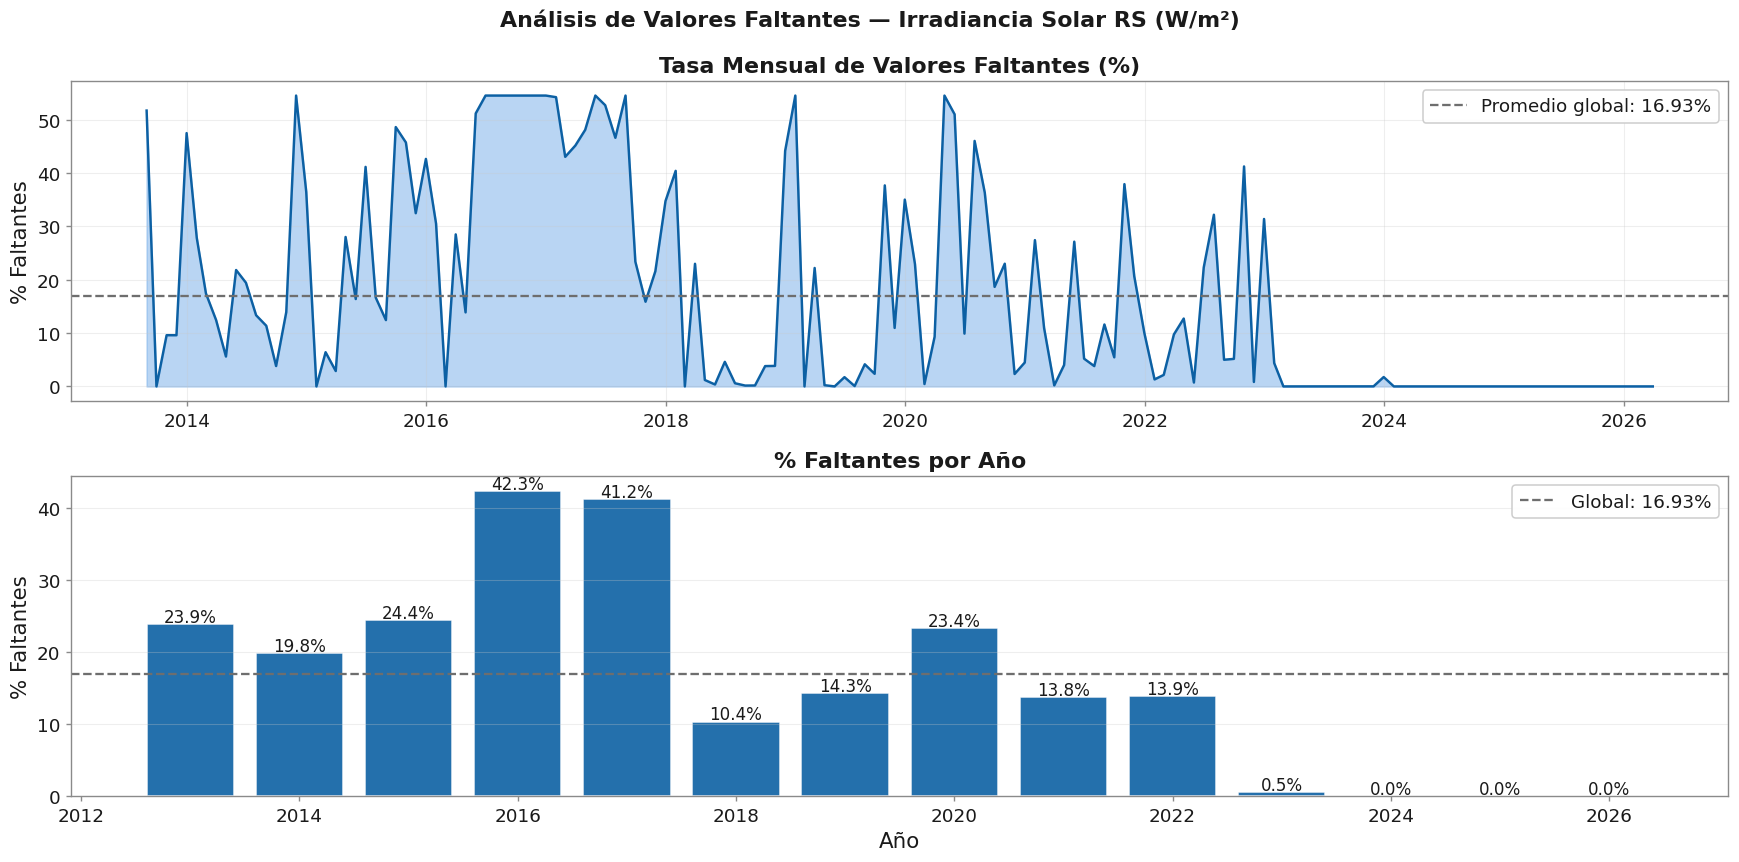

Guardado: fig_01a_faltantes.svg


In [ ]:
# Visualización de faltantes
falt_mes = df['RS'].isnull().resample('ME').mean() * 100

fig, axes = plt.subplots(2, 1, figsize=(16, 8))
fig.suptitle('Análisis de Valores Faltantes — Irradiancia Solar RS (W/m²)',
             fontsize=14.5, fontweight='bold')

# Panel 1: tasa mensual
axes[0].fill_between(falt_mes.index, falt_mes.values, alpha=0.55, color=C_AZUL_CLARO)
axes[0].plot(falt_mes.index, falt_mes.values, color=C_AZUL, lw=1.6)
axes[0].axhline(pct_nulos, color=C_GRIS, lw=1.5, ls='--',
                label=f'Promedio global: {pct_nulos:.2f}%')
axes[0].set_title('Tasa Mensual de Valores Faltantes (%)')
axes[0].set_ylabel('% Faltantes')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: % faltantes por año
axes[1].bar(falt_anio.index, falt_anio['Pct_%'],
            color=C_AZUL, alpha=0.9, edgecolor='white')
axes[1].axhline(pct_nulos, color=C_GRIS, lw=1.5, ls='--',
                label=f'Global: {pct_nulos:.2f}%')
for yr, row in falt_anio.iterrows():
    axes[1].text(yr, row['Pct_%'] + 0.3, f"{row['Pct_%']:.1f}%",
                 ha='center', fontsize=11)
axes[1].set_title('% Faltantes por Año')
axes[1].set_ylabel('% Faltantes')
axes[1].set_xlabel('Año')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
guardar_figura(plt.gcf(), 'fig_01a_faltantes')
plt.show()
print('Guardado: fig_01a_faltantes.svg')

In [ ]:
# Análisis de gaps en el índice temporal
idx_esp     = pd.date_range(start=df.index.min(), end=df.index.max(), freq='5min')
ts_ausentes = idx_esp.difference(df.index)

print('GAPS TEMPORALES (timestamps ausentes en el índice)')
print('=' * 52)
print(f'  Esperados    : {len(idx_esp):,}')
print(f'  Presentes    : {len(df):,}')
print(f'  Ausentes     : {len(ts_ausentes):,}  ({len(ts_ausentes)/len(idx_esp)*100:.3f}%)')

if len(ts_ausentes) > 0:
    # Identificar bloques continuos de gaps
    s_aus   = pd.Series(ts_ausentes)
    g_diffs = s_aus.diff()
    n_bloq  = (g_diffs != pd.Timedelta('5min')).sum()
    print(f'  Bloques continuos: {n_bloq:,}')
    print(f'\n  Primeros 10 ausentes:')
    print(ts_ausentes[:10].tolist())
else:
    print('  Sin gaps en el índice temporal')

GAPS TEMPORALES (timestamps ausentes en el índice)
  Esperados    : 1,330,560
  Presentes    : 1,330,560
  Ausentes     : 0  (0.000%)
  Sin gaps en el índice temporal


In [ ]:
# 4. Estadisticas descriptivas
#
# PARCHE DE LA REVISION: la franja diurna se define por la hora del reloj,
# igual que en los cuadernos 06, 07, 09 y 10. La definicion antigua, "RS > 0",
# se conserva para poder comparar, pero no es la que va al documento: excluye
# los instantes diurnos realmente oscuros y por eso da una media mas alta.
HORA_INI_DIURNO, HORA_FIN_DIURNO = 6, 18   # franja diurna del documento

rs        = df['RS'].dropna()
banda     = (rs.index.hour >= HORA_INI_DIURNO) & (rs.index.hour <= HORA_FIN_DIURNO)
rs_banda  = rs[banda]                 # franja diurna por reloj  <- la del documento
rs_pos    = rs[rs > 0]                # definicion antigua, solo para contraste

print('ESTADISTICAS DESCRIPTIVAS — RS (irradiancia solar, W/m2)')
print('=' * 64)
print(f'  N total                    : {n_total:,}')
print(f'  N validos                  : {len(rs):,}  ({len(rs)/n_total*100:.2f} %)')
print(f'  N en franja diurna (6-18h) : {len(rs_banda):,}  '
      f'({len(rs_banda)/len(rs)*100:.2f} % de validos)')
print(f'  N con RS > 0               : {len(rs_pos):,}  '
      f'({len(rs_pos)/len(rs)*100:.2f} % de validos)')
print()
print(f'  Minimo                     : {rs.min():.4f} W/m2')
print(f'  Maximo                     : {rs.max():.4f} W/m2')
print(f'  Media, todos los registros : {rs.mean():.4f} W/m2')
print(f'  Media, franja diurna       : {rs_banda.mean():.4f} W/m2   <- la del documento')
print(f'  Media, criterio RS > 0     : {rs_pos.mean():.4f} W/m2   (definicion antigua)')
print(f'  Mediana                    : {rs.median():.4f} W/m2')
print(f'  Desviacion estandar        : {rs.std():.4f} W/m2')
print(f'  Coeficiente de variacion   : {rs.std()/rs.mean()*100:.2f} %')
print()
print('  Percentiles de la franja diurna:')
for q in [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]:
    print(f'    P{int(q*100):>3}: {rs_banda.quantile(q):>10.4f} W/m2')
print()
print('  Asimetria y curtosis (NO citar en el cuerpo del documento; la direccion')
print('  pidio retirarlas porque no orientan ninguna decision del trabajo):')
print(f'    Asimetria : {rs.skew():.4f}')
print(f'    Curtosis  : {rs.kurtosis():.4f}')

estadisticos = {
    'N_total'            : n_total,
    'N_validos'          : len(rs),
    'N_franja_diurna'    : len(rs_banda),
    'N_rs_positivo'      : len(rs_pos),
    'Min'                : rs.min(),
    'Max'                : rs.max(),
    'Media_total'        : rs.mean(),
    'Media_franja_diurna': rs_banda.mean(),
    'Media_rs_positivo'  : rs_pos.mean(),
    'Mediana'            : rs.median(),
    'Std'                : rs.std(),
    'CV_%'               : rs.std()/rs.mean()*100,
    'Asimetria_anexo'    : rs.skew(),
    'Curtosis_anexo'     : rs.kurtosis(),
}
for q in [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]:
    estadisticos[f'P{int(q*100)}_franja_diurna'] = rs_banda.quantile(q)

pd.Series(estadisticos).to_csv(os.path.join(RUTA_DATOS, 'tabla_01_descriptivos.csv'))
print()
print('Guardado: tabla_01_descriptivos.csv')

ESTADISTICAS DESCRIPTIVAS — RS (irradiancia solar, W/m2)
  N total                    : 1,330,560
  N validos                  : 1,105,316  (83.07 %)
  N en franja diurna (6-18h) : 496,923  (44.96 % de validos)
  N con RS > 0               : 426,136  (38.55 % de validos)

  Minimo                     : 0.0000 W/m2
  Maximo                     : 1559.0000 W/m2
  Media, todos los registros : 118.5294 W/m2
  Media, franja diurna       : 263.6441 W/m2   <- la del documento
  Media, criterio RS > 0     : 307.4427 W/m2   (definicion antigua)
  Mediana                    : 0.0000 W/m2
  Desviacion estandar        : 222.5010 W/m2
  Coeficiente de variacion   : 187.72 %

  Percentiles de la franja diurna:
    P 10:     0.0000 W/m2
    P 25:    44.0000 W/m2
    P 50:   202.0000 W/m2
    P 75:   374.0000 W/m2
    P 90:   637.0000 W/m2
    P 95:   874.0000 W/m2
    P 99:  1118.0000 W/m2

  Asimetria y curtosis (NO citar en el cuerpo del documento; la direccion
  pidio retirarlas porque no orientan

  Figura guardada: fig_01b_distribucion.png, .svg y .pdf


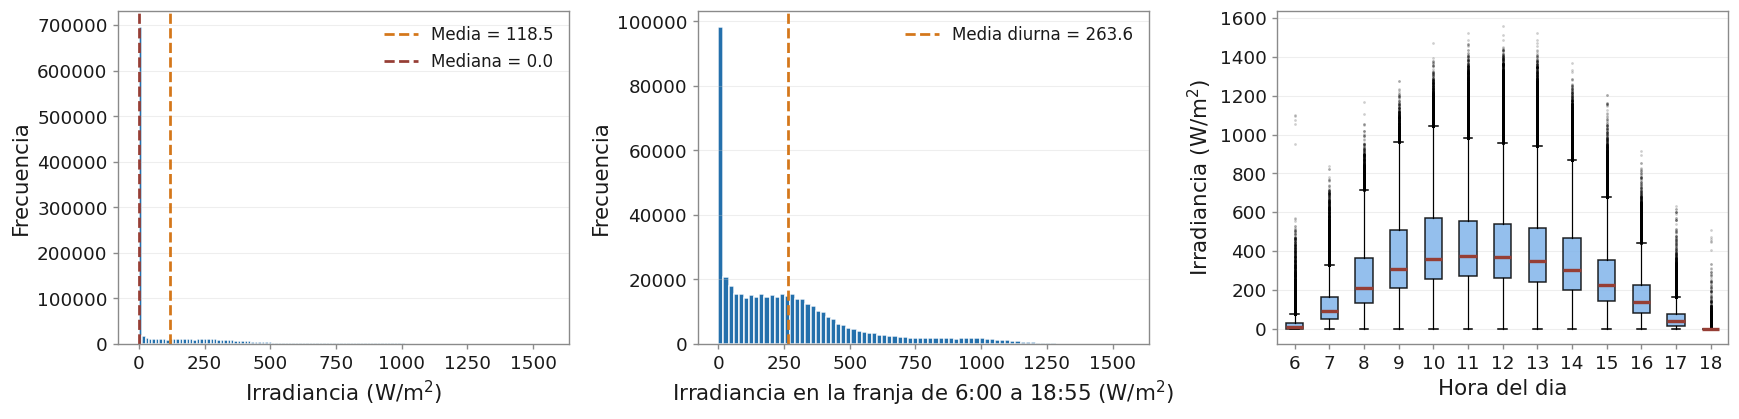

Guardado: fig_01b_distribucion.svg
Sin titulo dentro de la imagen: el pie de figura del documento lo aporta.


In [ ]:
# 5. Distribucion de la irradiancia
#
# PARCHE DE LA REVISION: los tres paneles usan la franja diurna por reloj
# (6:00 a 18:55), la misma definicion que el resto de los cuadernos. Antes el
# panel central y el diagrama de cajas filtraban por "RS > 0", que deja fuera
# los instantes diurnos realmente oscuros.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Panel 1: distribucion completa, todos los registros validos
axes[0].hist(rs, bins=120, color=C_AZUL, alpha=0.9, edgecolor='white')
axes[0].axvline(rs.mean(), color=C_AMBAR, lw=1.8, ls='--',
                label=f'Media = {rs.mean():.1f}')
axes[0].axvline(rs.median(), color=C_TEJA, lw=1.8, ls='--',
                label=f'Mediana = {rs.median():.1f}')
axes[0].set_xlabel('Irradiancia (W/m$^2$)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(fontsize=11, frameon=False)
axes[0].grid(True, alpha=0.3, axis='y')

# Panel 2: solo la franja diurna
axes[1].hist(rs_banda, bins=80, color=C_AZUL, alpha=0.9, edgecolor='white')
axes[1].axvline(rs_banda.mean(), color=C_AMBAR, lw=1.8, ls='--',
                label=f'Media diurna = {rs_banda.mean():.1f}')
axes[1].set_xlabel('Irradiancia en la franja de 6:00 a 18:55 (W/m$^2$)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend(fontsize=11, frameon=False)
axes[1].grid(True, alpha=0.3, axis='y')

# Panel 3: distribucion por hora, dentro de la franja diurna
df_box = pd.DataFrame({'hora': df.index.hour, 'RS': df['RS'].values}).dropna()
df_box = df_box[(df_box['hora'] >= HORA_INI_DIURNO) &
                (df_box['hora'] <= HORA_FIN_DIURNO)]
horas_caja = list(range(HORA_INI_DIURNO, HORA_FIN_DIURNO + 1))
datos_box = [df_box.loc[df_box['hora'] == h, 'RS'].values for h in horas_caja]
axes[2].boxplot(datos_box, tick_labels=horas_caja, patch_artist=True,
                boxprops=dict(facecolor=C_AZUL_CLARO, alpha=0.85),
                medianprops=dict(color=C_TEJA, lw=2.2),
                flierprops=dict(marker='.', ms=1.5, alpha=0.2),
                whiskerprops=dict(lw=0.8))
axes[2].set_xlabel('Hora del dia')
axes[2].set_ylabel('Irradiancia (W/m$^2$)')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
guardar_figura(plt.gcf(), 'fig_01b_distribucion')
plt.show()
print('Guardado: fig_01b_distribucion.svg')
print('Sin titulo dentro de la imagen: el pie de figura del documento lo aporta.')

  Figura guardada: fig_01c_patrones_temporales.png, .svg y .pdf


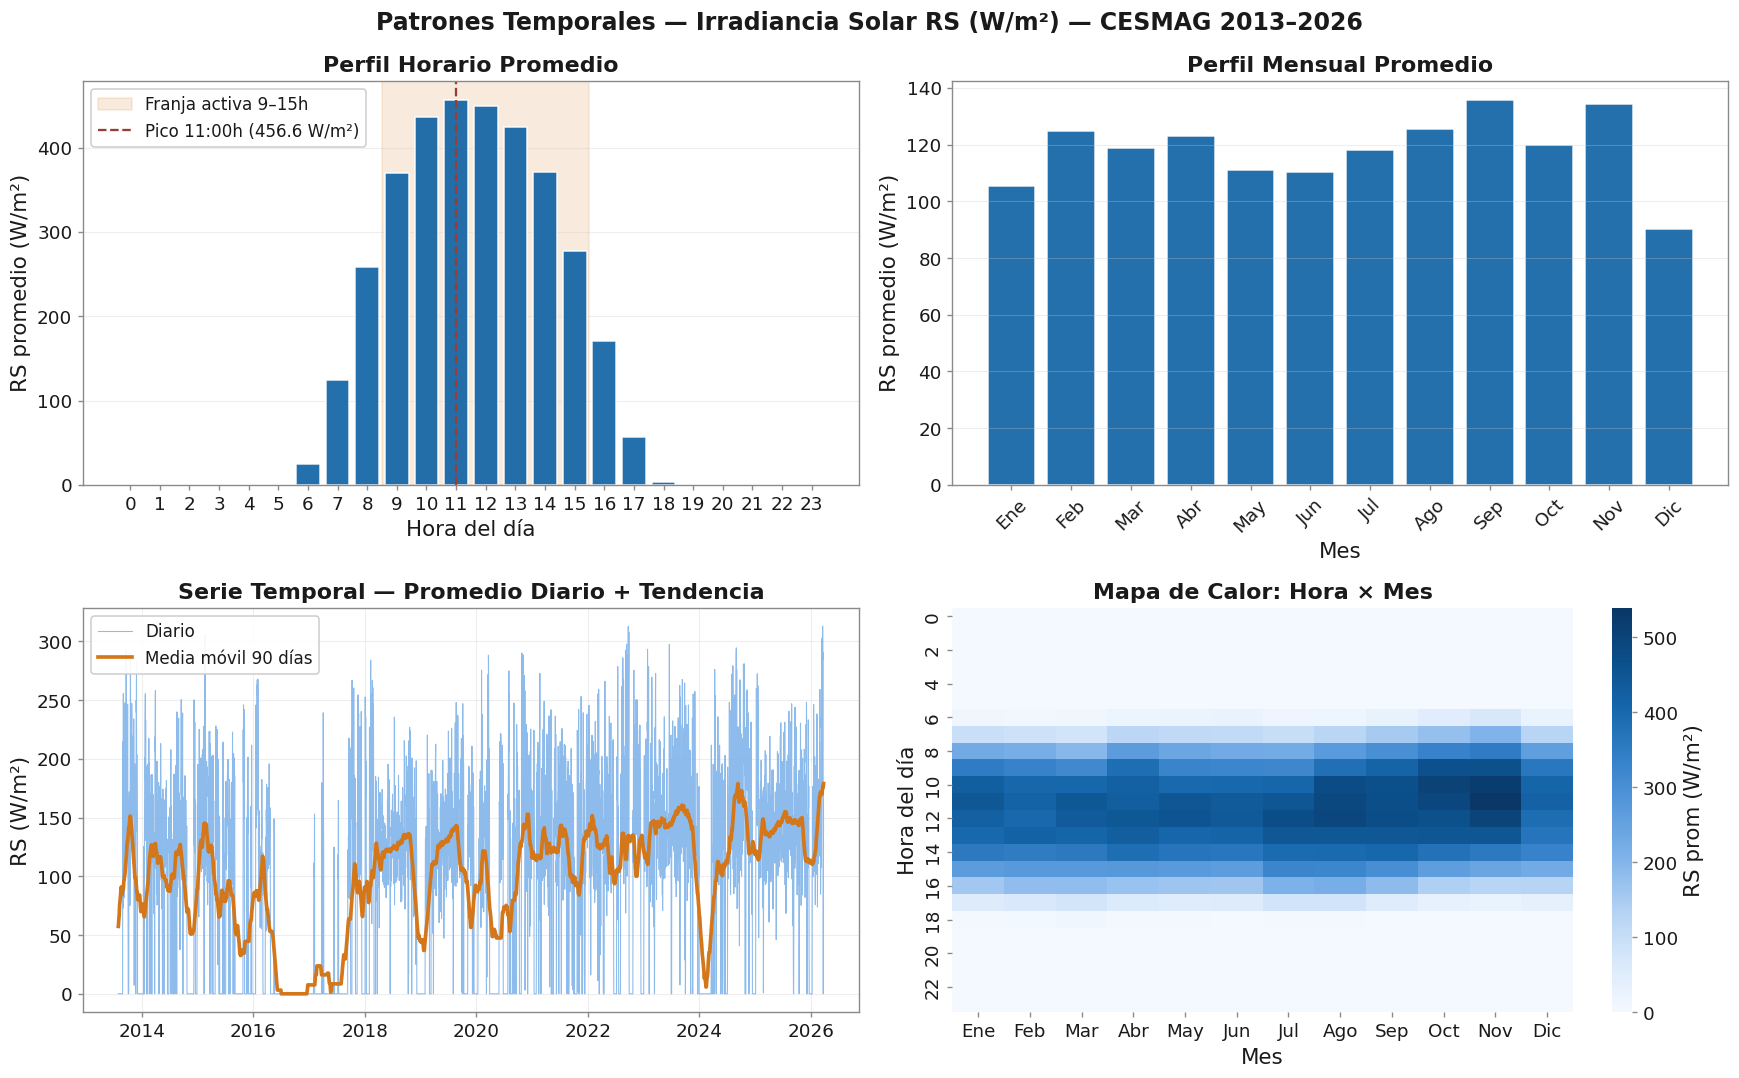

Guardado: fig_01c_patrones_temporales.svg


In [ ]:
# ── 6. Patrones temporales ────────────────────────────────────────────────
mes_etiq = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Patrones Temporales — Irradiancia Solar RS (W/m²) — CESMAG 2013–2026',
             fontsize=15.5, fontweight='bold')

# Perfil horario promedio
ph = df['RS'].groupby(df.index.hour).mean()
axes[0,0].bar(ph.index, ph.values, color=C_AZUL, alpha=0.9, edgecolor='white', zorder=2)
axes[0,0].axvspan(8.5, 15.5, alpha=0.14, color=C_AMBAR, zorder=1, label='Franja activa 9–15h')
axes[0,0].axvline(ph.idxmax(), color=C_TEJA, lw=1.5, ls='--',
                   label=f'Pico {ph.idxmax()}:00h ({ph.max():.1f} W/m²)')
axes[0,0].set_title('Perfil Horario Promedio')
axes[0,0].set_xlabel('Hora del día')
axes[0,0].set_ylabel('RS promedio (W/m²)')
axes[0,0].set_xticks(range(0, 24))
axes[0,0].legend(fontsize=11)
axes[0,0].grid(True, alpha=0.3, axis='y')

# Perfil mensual promedio
pm = df['RS'].groupby(df.index.month).mean()
axes[0,1].bar(pm.index, pm.values, color=C_AZUL, alpha=0.9, edgecolor='white')
axes[0,1].set_title('Perfil Mensual Promedio')
axes[0,1].set_xlabel('Mes')
axes[0,1].set_ylabel('RS promedio (W/m²)')
axes[0,1].set_xticks(range(1, 13))
axes[0,1].set_xticklabels(mes_etiq, rotation=45)
axes[0,1].grid(True, alpha=0.3, axis='y')

# Serie diaria + media móvil 90 días
rs_d  = df['RS'].resample('D').mean()
rs_ma = rs_d.rolling(90, center=True, min_periods=30).mean()
axes[1,0].plot(rs_d.index, rs_d.values, color=C_AZUL_CLARO, lw=0.7, alpha=0.9, label='Diario')
axes[1,0].plot(rs_ma.index, rs_ma.values, color=C_AMBAR, lw=2.4, label='Media móvil 90 días')
axes[1,0].set_title('Serie Temporal — Promedio Diario + Tendencia')
axes[1,0].set_ylabel('RS (W/m²)')
axes[1,0].legend(fontsize=11)
axes[1,0].grid(True, alpha=0.3)
eje_fechas(axes[1,0])

# Mapa de calor hora × mes
df_hm = pd.DataFrame({'h': df.index.hour, 'm': df.index.month, 'RS': df['RS'].values})
pivot = df_hm.groupby(['h','m'])['RS'].mean().unstack()
sns.heatmap(pivot, ax=axes[1,1], cmap='tg_azul',
            xticklabels=mes_etiq, cbar_kws={'label': 'RS prom (W/m²)'})
axes[1,1].set_title('Mapa de Calor: Hora × Mes')
axes[1,1].set_xlabel('Mes')
axes[1,1].set_ylabel('Hora del día')

plt.tight_layout()
guardar_figura(plt.gcf(), 'fig_01c_patrones_temporales')
plt.show()
print('Guardado: fig_01c_patrones_temporales.svg')

  Figura guardada: fig_01d_perfil_por_anio.png, .svg y .pdf


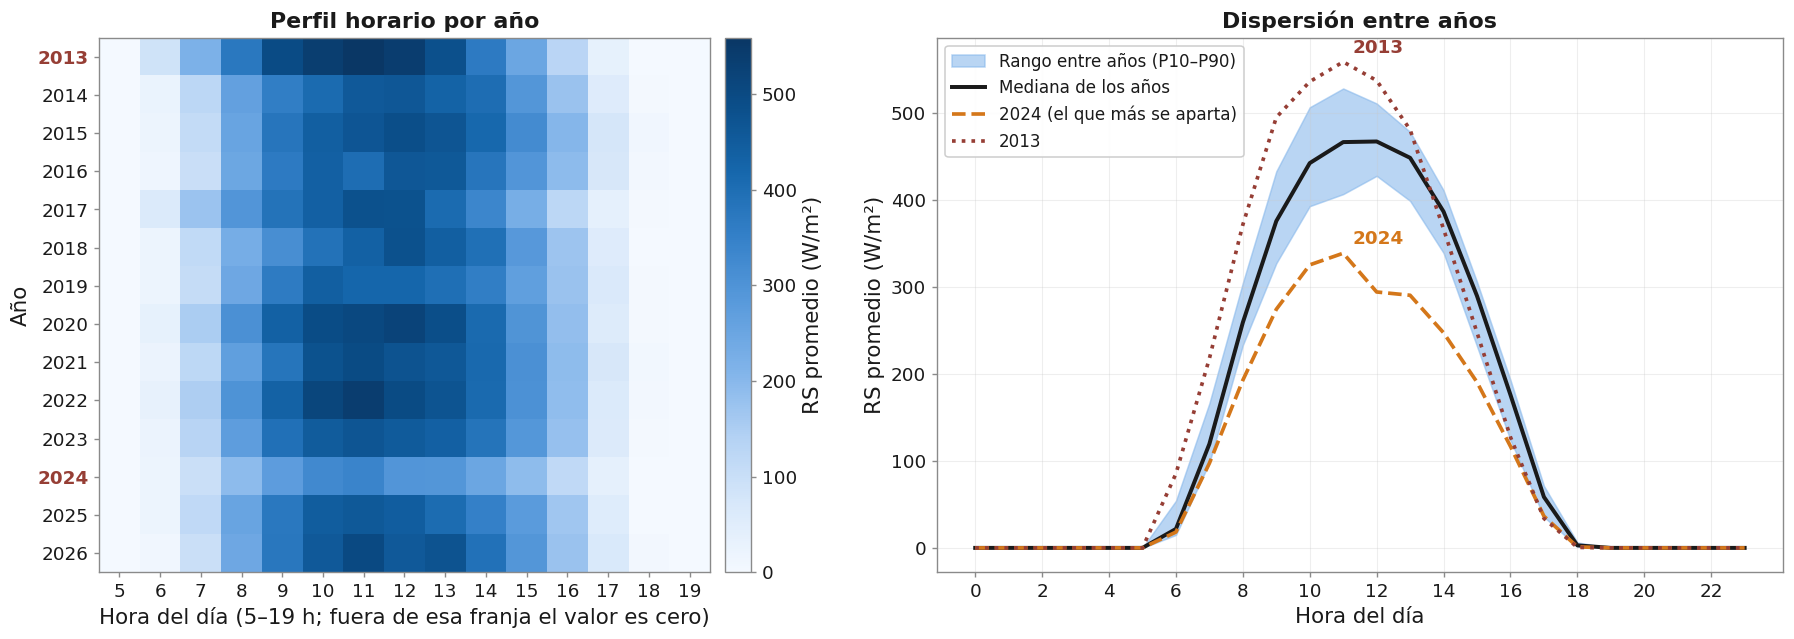

DESVIO DE CADA ANIO RESPECTO A LA MEDIANA (franja con luz, W/m2)
  Anio     Desvio   Cobertura   Nota
  2024      83.94     100.0%   se aparta de los demas
  2013      63.05      31.9%   anio incompleto
  2017      30.90      58.8%   
  2022      29.37      86.1%   
  2020      28.26      76.6%   
  2019      19.43      85.7%   
  2018      17.47      89.6%   
  2016      14.17      57.7%   
  2015      13.26      75.6%   
  2021      13.03      86.2%   
  2026      11.81      23.0%   
  2025      11.76     100.0%   
  2014       9.17      80.2%   
  2023       6.79      99.5%   

Guardado: fig_01d_perfil_por_anio (png, svg y pdf)


In [ ]:
# Perfil horario por año — detecta cambios de comportamiento o fallas del sensor
#
# PARCHE DE LA REVISION. Antes esto eran catorce curvas superpuestas, una por
# anio. Catorce colores no se distinguen: ni en una rampa de azules, ni en
# ninguna otra paleta. La pregunta que la figura debe responder no es "que
# color es 2019", sino "hay algun anio que se comporte distinto de los demas".
# Se responde con dos paneles:
#   - Izquierda: mapa de calor anio x hora. Una fila mas clara salta a la vista.
#   - Derecha:   perfil mediano entre anios con su banda P10-P90, y encima los
#                DOS anios que mas se apartan, con nombre pegado a la curva.
anios = sorted(df.index.year.unique())
horas = np.arange(24)

perfiles = {}
for a in anios:
    s = df['RS'][df.index.year == a]
    perfiles[a] = s.groupby(s.index.hour).mean().reindex(horas)
P = pd.DataFrame(perfiles).T          # filas = anio, columnas = hora

mediana = P.median(axis=0)
p10, p90 = P.quantile(0.10, axis=0), P.quantile(0.90, axis=0)

# Cuanto se aparta cada anio de la mediana, dentro de la franja con luz
banda = (horas >= HORA_INI_DIURNO) & (horas <= HORA_FIN_DIURNO)
desvio = (P.loc[:, banda].sub(mediana[banda], axis=1).abs().mean(axis=1)
           .sort_values(ascending=False))
destacados = list(desvio.index[:2])

fig, (ax_map, ax_lin) = plt.subplots(1, 2, figsize=(16.5, 6),
                                     gridspec_kw={'width_ratios': [1, 1.15]})

# --- Panel izquierdo: mapa de calor anio x hora --------------------------
h_ini, h_fin = 5, 19                   # fuera de esta franja el valor es cero
sub = P.loc[:, h_ini:h_fin]
im = ax_map.imshow(sub.values, aspect='auto', cmap='tg_azul',
                   extent=[h_ini - 0.5, h_fin + 0.5, len(anios) - 0.5, -0.5])
ax_map.set_yticks(range(len(anios)))
ax_map.set_yticklabels([str(a) for a in anios])
ax_map.set_xticks(range(h_ini, h_fin + 1))
ax_map.set_xlabel('Hora del día (5–19 h; fuera de esa franja el valor es cero)')
ax_map.set_ylabel('Año')
ax_map.set_title('Perfil horario por año')
cb = fig.colorbar(im, ax=ax_map, pad=0.02)
cb.set_label('RS promedio (W/m²)')
for a in destacados:                    # marca los anios atipicos en el eje
    ax_map.get_yticklabels()[anios.index(a)].set_color(C_TEJA)
    ax_map.get_yticklabels()[anios.index(a)].set_fontweight('bold')

# --- Panel derecho: mediana, banda entre anios y los dos atipicos --------
ax_lin.fill_between(horas, p10.values, p90.values, color=C_AZUL_CLARO,
                    alpha=0.55, label='Rango entre años (P10–P90)')
ax_lin.plot(horas, mediana.values, color=C_TEXTO, lw=2.6,
            label='Mediana de los años')
for a, col, trazo in zip(destacados, [C_AMBAR, C_TEJA], ['--', ':']):
    ax_lin.plot(horas, P.loc[a].values, color=col, lw=2.4, ls=trazo,
                label=f'{a} (el que más se aparta)' if a == destacados[0] else str(a))
    h_pico = int(np.nanargmax(P.loc[a].values))
    ax_lin.annotate(str(a), xy=(h_pico, P.loc[a].values[h_pico]),
                    xytext=(6, 6), textcoords='offset points',
                    color=col, fontweight='bold', fontsize=12)
ax_lin.set_xticks(range(0, 24, 2))
ax_lin.set_xlabel('Hora del día')
ax_lin.set_ylabel('RS promedio (W/m²)')
ax_lin.set_title('Dispersión entre años')
ax_lin.legend(fontsize=11, loc='upper left')
ax_lin.grid(True, alpha=0.3)

plt.tight_layout()
guardar_figura(plt.gcf(), 'fig_01d_perfil_por_anio')
plt.show()

# La cobertura ayuda a leer la tabla: un anio incompleto se aparta por tener
# solo unos meses, no porque el sensor haya fallado. Son dos cosas distintas.
cobertura_anio = {}
for a in anios:
    s = df['RS'][df.index.year == a]
    esperados = pd.date_range(f'{a}-01-01', f'{a}-12-31 23:55', freq='5min')
    cobertura_anio[a] = s.notna().sum() / len(esperados)

print('DESVIO DE CADA ANIO RESPECTO A LA MEDIANA (franja con luz, W/m2)')
print('=' * 68)
print(f'  {"Anio":<6} {"Desvio":>8}  {"Cobertura":>10}   Nota')
for a, d in desvio.items():
    cob = cobertura_anio[a]
    if a in destacados:
        nota = 'anio incompleto' if cob < 0.75 else 'se aparta de los demas'
    else:
        nota = ''
    print(f'  {a:<6} {d:8.2f}  {cob:9.1%}   {nota}')
print()
print('Guardado: fig_01d_perfil_por_anio (png, svg y pdf)')


In [ ]:
# ── 7. Detección de valores atípicos ─────────────────────────────────────

# Método IQR
q1  = rs.quantile(0.25)
q3  = rs.quantile(0.75)
iqr = q3 - q1
li  = q1 - 1.5 * iqr
ls  = q3 + 1.5 * iqr

n_inf = (rs < li).sum()
n_sup = (rs > ls).sum()

print('DETECCIÓN DE OUTLIERS')
print('=' * 55)
print('Método IQR × 1.5:')
print(f'  Q1={q1:.2f}  Q3={q3:.2f}  IQR={iqr:.2f}')
print(f'  Límite inferior : {li:.2f} W/m²')
print(f'  Límite superior : {ls:.2f} W/m²')
print(f'  Outliers inf    : {n_inf:,}  ({n_inf/len(rs)*100:.3f}%)')
print(f'  Outliers sup    : {n_sup:,}  ({n_sup/len(rs)*100:.3f}%)')
print()
print('Límites físicos:')
print(f'  RS < 0   (imposible)    : {(df["RS"] < 0).sum():,}')
print(f'  RS > 1400 (sospechoso)  : {(df["RS"] > 1400).sum():,}')
print(f'  RS > 1559 (máx docum.)  : {(df["RS"] > 1559).sum():,}')
print()
print('Top 15 valores máximos:')
print(df['RS'].nlargest(15).to_string())

# Guardar tabla
pd.DataFrame({
    'Metodo': ['IQR x1.5','Fisico'],
    'Lim_inf': [round(li,2), 0],
    'Lim_sup': [round(ls,2), 1559],
    'N_out_inf': [n_inf, (df['RS']<0).sum()],
    'N_out_sup': [n_sup, (df['RS']>1559).sum()]
}).to_csv(os.path.join(RUTA_DATOS, 'tabla_01_outliers.csv'), index=False)
print('\nGuardado: tabla_01_outliers.csv')

DETECCIÓN DE OUTLIERS
Método IQR × 1.5:
  Q1=0.00  Q3=166.00  IQR=166.00
  Límite inferior : -249.00 W/m²
  Límite superior : 415.00 W/m²
  Outliers inf    : 0  (0.000%)
  Outliers sup    : 103,679  (9.380%)

Límites físicos:
  RS < 0   (imposible)    : 0
  RS > 1400 (sospechoso)  : 55
  RS > 1559 (máx docum.)  : 0

Top 15 valores máximos:
timestamp
2023-03-18 12:15:00    1559.0
2015-03-02 13:20:00    1524.0
2017-09-18 11:40:00    1522.0
2013-09-10 12:55:00    1512.0
2020-09-04 11:25:00    1488.0
2015-03-17 13:40:00    1487.0
2020-10-02 12:20:00    1487.0
2020-10-08 10:40:00    1473.0
2015-03-02 13:15:00    1471.0
2013-09-13 11:30:00    1468.0
2013-10-10 11:10:00    1466.0
2013-10-10 11:05:00    1461.0
2015-02-25 11:55:00    1457.0
2023-04-06 13:30:00    1456.0
2023-03-18 12:30:00    1450.0

Guardado: tabla_01_outliers.csv


  Figura guardada: fig_01e_outliers.png, .svg y .pdf


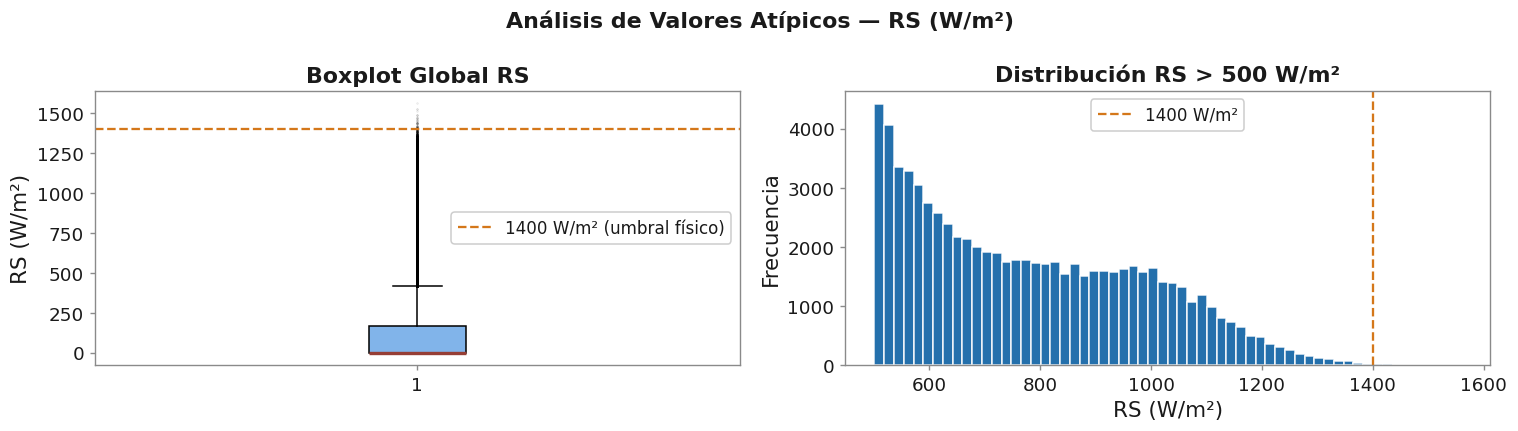

Guardado: fig_01e_outliers.svg


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Análisis de Valores Atípicos — RS (W/m²)', fontsize=14.5, fontweight='bold')

# Boxplot global
axes[0].boxplot(rs, vert=True, patch_artist=True,
                boxprops=dict(facecolor=C_AZUL_CLARO),
                medianprops=dict(color=C_TEJA, lw=2.2),
                flierprops=dict(marker='.', ms=1, alpha=0.1))
axes[0].axhline(1400, color=C_AMBAR, lw=1.5, ls='--', label='1400 W/m² (umbral físico)')
axes[0].set_title('Boxplot Global RS')
axes[0].set_ylabel('RS (W/m²)')
axes[0].legend(fontsize=11)

# Histograma zona alta
rs_alta = rs[rs > 500]
axes[1].hist(rs_alta, bins=60, color=C_AZUL, alpha=0.9, edgecolor='white')
axes[1].axvline(1400, color=C_AMBAR, lw=1.5, ls='--', label='1400 W/m²')
axes[1].set_title('Distribución RS > 500 W/m²')
axes[1].set_xlabel('RS (W/m²)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend(fontsize=11)

plt.tight_layout()
guardar_figura(plt.gcf(), 'fig_01e_outliers')
plt.show()
print('Guardado: fig_01e_outliers.svg')

In [ ]:
# ── 8. Resumen de hallazgos ───────────────────────────────────────────────
hora_pico = ph.idxmax()
mes_max   = pm.idxmax()

print('=' * 65)
print('RESUMEN DE HALLAZGOS — BASE PARA PREPROCESAMIENTO (Notebook 02)')
print('=' * 65)
print(f"""
DATASET
  Fuente     : Estación Davis Vantage Pro — Universidad CESMAG, Pasto
  Período    : {df.index.min().date()} → {df.index.max().date()}
  Registros  : {len(df):,}  |  Resolución: 5 minutos
  Variables  : DateTime + Irradiancia (RS)

CALIDAD DE DATOS
  Faltantes  : {n_nulos:,}  ({pct_nulos:.3f}%)
  Cobertura  : {cobertura:.3f}%
  RS < 0     : {int((df['RS']<0).sum()):,}  → corregir a 0
  RS > 1400  : {int((df['RS']>1400).sum()):,}  → revisar

ESTADÍSTICAS CLAVE
  Rango      : {rs.min():.2f} – {rs.max():.2f} W/m²
  Media      : {rs.mean():.2f} W/m²  |  Std: {rs.std():.2f} W/m²
  Asimetría  : {rs.skew():.3f}  (distribución sesgada a la derecha)
  Pico diurno: ~{hora_pico}:00h  |  Mes mayor irrad.: {mes_etiq[mes_max-1]}

ACCIONES DE PREPROCESAMIENTO (Notebook 02)
  1. Construir índice completo a 5 min (rellenar gaps temporales)
  2. Corregir RS < 0 → asignar 0
  3. Imputar faltantes por promedio histórico hora × mes
  4. Integrar NASA POWER (horario → interpolar a 5 min)
  5. Crear variables temporales cíclicas (sin/cos hora, mes, día_año)
  6. Calcular índice de claridad KT = ALLSKY / CLRSKY
  7. Normalizar con MinMaxScaler
  8. Particionar train/val/test respetando orden temporal
""")

print('Archivos generados en /datos/:')
for f in sorted(os.listdir(RUTA_DATOS)):
    tam = os.path.getsize(os.path.join(RUTA_DATOS, f)) / 1024
    print(f'  {f:<45} ({tam:>7.1f} KB)')

print('\nFiguras generadas en /figuras_SVG/:')
for f in sorted(os.listdir(RUTA_FIGS_SVG)):
    tam = os.path.getsize(os.path.join(RUTA_FIGS_SVG, f)) / 1024
    print(f'  {f:<45} ({tam:>7.1f} KB)')

print('\n✓ Notebook 01 completado.')
print('  Siguiente: 02_preprocesamiento.ipynb')

RESUMEN DE HALLAZGOS — BASE PARA PREPROCESAMIENTO (Notebook 02)

DATASET
  Fuente     : Estación Davis Vantage Pro — Universidad CESMAG, Pasto
  Período    : 2013-08-01 → 2026-03-25
  Registros  : 1,330,560  |  Resolución: 5 minutos
  Variables  : DateTime + Irradiancia (RS)

CALIDAD DE DATOS
  Faltantes  : 225,244  (16.929%)
  Cobertura  : 100.000%
  RS < 0     : 0  → corregir a 0
  RS > 1400  : 55  → revisar

ESTADÍSTICAS CLAVE
  Rango      : 0.00 – 1559.00 W/m²
  Media      : 118.53 W/m²  |  Std: 222.50 W/m²
  Asimetría  : 2.409  (distribución sesgada a la derecha)
  Pico diurno: ~11:00h  |  Mes mayor irrad.: Sep

ACCIONES DE PREPROCESAMIENTO (Notebook 02)
  1. Construir índice completo a 5 min (rellenar gaps temporales)
  2. Corregir RS < 0 → asignar 0
  3. Imputar faltantes por promedio histórico hora × mes
  4. Integrar NASA POWER (horario → interpolar a 5 min)
  5. Crear variables temporales cíclicas (sin/cos hora, mes, día_año)
  6. Calcular índice de claridad KT = ALLSKY / CLR